In [52]:
import warnings

warnings.filterwarnings('ignore')

## Extracción del Archivo Tratado

In [53]:
import pandas as pd

archivo = '/content/drive/MyDrive/ONE/6. Estadisticas y Machine Learning/8. Telecom X: análisis de evasión de clientes - Parte 2/datos_tratados.csv'
# archivo = '/content/datos_tratados.csv'

datos = pd.read_csv(archivo)

In [54]:
# Ver todas las filas al visualizar dataframes
# pd.set_option('display.max_rows',None)

# Ver todas las columnas al visualizar dataframes
pd.set_option('display.max_columns',None)

In [55]:
datos.head(2)

,id_cliente,Churn,genero,adulto_mayor,tiene_pareja,tiene_dependientes,antiguedad_meses,servicio_telefono,lineas_multiples,tipo_internet,seguridad_online,respaldo_online,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_electronica,metodo_pago,cobro_mensual,cobro_total,cobro_diario
0,0002-ORFBO,No,Femenino,No,Sí,Sí,9,Sí,No,DSL,No,Sí,No,Sí,Sí,No,Un año,Sí,Cheque por correo,65.6,593.3,2.186667
1,0003-MKNFE,No,Masculino,No,No,No,9,Sí,Sí,DSL,No,No,No,No,No,Sí,Mes a mes,No,Cheque por correo,59.9,542.4,1.996667


In [56]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id_cliente              7032 non-null   object 
 1   Churn                   7032 non-null   object 
 2   genero                  7032 non-null   object 
 3   adulto_mayor            7032 non-null   object 
 4   tiene_pareja            7032 non-null   object 
 5   tiene_dependientes      7032 non-null   object 
 6   antiguedad_meses        7032 non-null   int64  
 7   servicio_telefono       7032 non-null   object 
 8   lineas_multiples        7032 non-null   object 
 9   tipo_internet           7032 non-null   object 
 10  seguridad_online        7032 non-null   object 
 11  respaldo_online         7032 non-null   object 
 12  proteccion_dispositivo  7032 non-null   object 
 13  soporte_tecnico         7032 non-null   object 
 14  streaming_tv            7032 non-null   

In [57]:
datos.describe()

,antiguedad_meses,cobro_mensual,cobro_total,cobro_diario
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441,2.159940
std,24.545260,30.085974,2266.771362,1.002866
min,1.000000,18.250000,18.800000,0.608333
25%,9.000000,35.587500,401.450000,1.186250
50%,29.000000,70.350000,1397.475000,2.345000
75%,55.000000,89.862500,3794.737500,2.995417
max,72.000000,118.750000,8684.800000,3.958333


In [58]:
datos.describe(include='O')

,id_cliente,Churn,genero,adulto_mayor,tiene_pareja,tiene_dependientes,servicio_telefono,lineas_multiples,tipo_internet,seguridad_online,respaldo_online,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_electronica,metodo_pago
count,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032
unique,7032,2,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4
top,9995-HOTOH,No,Masculino,No,No,No,Sí,No,Fibra óptica,No,No,No,No,No,No,Mes a mes,Sí,Cheque electrónico
freq,1,5163,3549,5890,3639,4933,6352,3385,3096,3497,3087,3094,3472,2809,2781,3875,4168,2365


## Feature Engineering: Eliminación de columnas irrelevantes

In [59]:
datos.drop(columns='id_cliente', inplace=True)

In [60]:
for columna in datos.columns:
  print(f'{columna}: {datos[columna].unique()}')

Churn: ['No' 'Sí']
genero: ['Femenino' 'Masculino']
adulto_mayor: ['No' 'Sí']
tiene_pareja: ['Sí' 'No']
tiene_dependientes: ['Sí' 'No']
antiguedad_meses: [ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 37 49 66 67
 20 43 59 12 27  2 25 29 14 35 64 39 40 11  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 31 36 17 18 51 38 42]
servicio_telefono: ['Sí' 'No']
lineas_multiples: ['No' 'Sí' 'Sin servicio telefónico']
tipo_internet: ['DSL' 'Fibra óptica' 'No']
seguridad_online: ['No' 'Sí' 'Sin servicio de internet']
respaldo_online: ['Sí' 'No' 'Sin servicio de internet']
proteccion_dispositivo: ['No' 'Sí' 'Sin servicio de internet']
soporte_tecnico: ['Sí' 'No' 'Sin servicio de internet']
streaming_tv: ['Sí' 'No' 'Sin servicio de internet']
streaming_peliculas: ['No' 'Sí' 'Sin servicio de internet']
tipo_contrato: ['Un año' 'Mes a mes' 'Dos años']
factura_electronica: ['Sí' 'No']
metodo_pago: ['Cheque por correo' 'Cheque electrónico'
 'Tarjeta de c

In [61]:
cols_a_limpiar = [
    'lineas_multiples', 'seguridad_online', 'respaldo_online',
    'proteccion_dispositivo', 'soporte_tecnico',
    'streaming_tv', 'streaming_peliculas'
]

mapping = {
    'Sin servicio telefónico': 'No',
    'Sin servicio de internet': 'No'
}


datos[cols_a_limpiar] = datos[cols_a_limpiar].replace(mapping)

In [62]:
for columna in datos.columns:
  print(f'{columna}: {datos[columna].unique()}')

Churn: ['No' 'Sí']
genero: ['Femenino' 'Masculino']
adulto_mayor: ['No' 'Sí']
tiene_pareja: ['Sí' 'No']
tiene_dependientes: ['Sí' 'No']
antiguedad_meses: [ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 37 49 66 67
 20 43 59 12 27  2 25 29 14 35 64 39 40 11  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 31 36 17 18 51 38 42]
servicio_telefono: ['Sí' 'No']
lineas_multiples: ['No' 'Sí']
tipo_internet: ['DSL' 'Fibra óptica' 'No']
seguridad_online: ['No' 'Sí']
respaldo_online: ['Sí' 'No']
proteccion_dispositivo: ['No' 'Sí']
soporte_tecnico: ['Sí' 'No']
streaming_tv: ['Sí' 'No']
streaming_peliculas: ['No' 'Sí']
tipo_contrato: ['Un año' 'Mes a mes' 'Dos años']
factura_electronica: ['Sí' 'No']
metodo_pago: ['Cheque por correo' 'Cheque electrónico'
 'Tarjeta de crédito (automática)' 'Transferencia bancaria (automática)']
cobro_mensual: [65.6  59.9  73.9  ... 91.75 68.8  67.85]
cobro_total: [ 593.3   542.4   280.85 ...  742.9  4627.65 3707.6 ]
cobr

### Correlación

In [63]:
cols_binarias = [
    'Churn', 'genero', 'adulto_mayor', 'tiene_pareja', 'tiene_dependientes',
    'servicio_telefono', 'lineas_multiples', 'seguridad_online',
    'respaldo_online', 'proteccion_dispositivo', 'soporte_tecnico',
    'streaming_tv', 'streaming_peliculas', 'factura_electronica'
]

df_analisis = datos.copy()

df_analisis[cols_binarias] = df_analisis[cols_binarias].apply(lambda x: x.map({'Sí': 1, 'No': 0, 'Femenino': 1, 'Masculino': 0}))

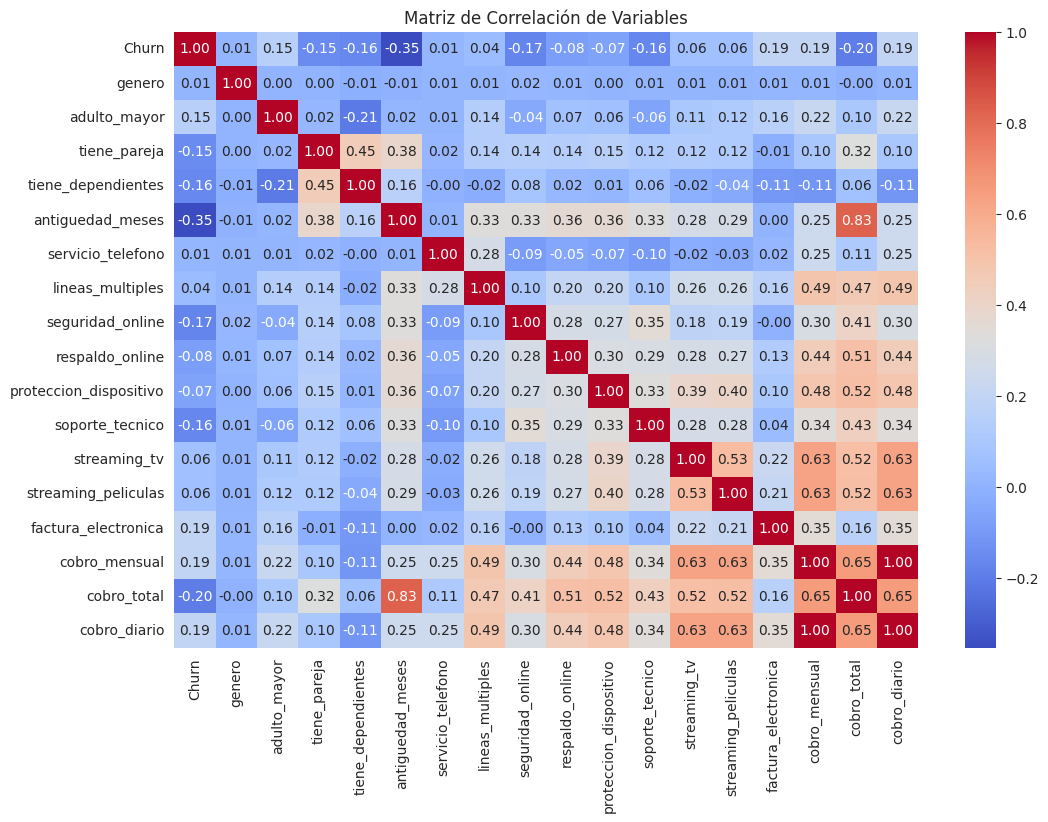

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

matriz_corr = df_analisis.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Matriz de Correlación de Variables")
plt.show()

In [65]:
matriz_corr['Churn']

,Churn
Churn,1.000000
genero,0.008545
adulto_mayor,0.150541
tiene_pareja,-0.149982
tiene_dependientes,-0.163128
antiguedad_meses,-0.354049
servicio_telefono,0.011691
lineas_multiples,0.040033
seguridad_online,-0.171270
respaldo_online,-0.082307


#### Eliminación de variables en base a la correlación

In [66]:
datos = datos.drop(columns=['genero', 'servicio_telefono', 'cobro_diario', 'cobro_total'])
datos.head()


,Churn,adulto_mayor,tiene_pareja,tiene_dependientes,antiguedad_meses,lineas_multiples,tipo_internet,seguridad_online,respaldo_online,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_electronica,metodo_pago,cobro_mensual
0,No,No,Sí,Sí,9,No,DSL,No,Sí,No,Sí,Sí,No,Un año,Sí,Cheque por correo,65.6
1,No,No,No,No,9,Sí,DSL,No,No,No,No,No,Sí,Mes a mes,No,Cheque por correo,59.9
2,Sí,No,No,No,4,No,Fibra óptica,No,No,Sí,No,No,No,Mes a mes,Sí,Cheque electrónico,73.9
3,Sí,Sí,Sí,No,13,No,Fibra óptica,No,Sí,Sí,No,Sí,Sí,Mes a mes,Sí,Cheque electrónico,98.0
4,Sí,Sí,Sí,No,3,No,Fibra óptica,No,No,No,Sí,Sí,No,Mes a mes,Sí,Cheque por correo,83.9


## Division de datos

In [67]:
from sklearn.model_selection import train_test_split

X = datos.drop(columns='Churn')
y = datos['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=5)


print(f"Train: {X_train.shape[0]} \nTest: {X_test.shape[0]}")

Train: 5625 
Test: 1407


## Transformer Encoder

In [68]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

cols_categoricas = [
    'adulto_mayor', 'tiene_pareja', 'tiene_dependientes',
    'lineas_multiples', 'tipo_internet', 'seguridad_online',
    'respaldo_online', 'proteccion_dispositivo', 'soporte_tecnico',
    'streaming_tv', 'streaming_peliculas', 'tipo_contrato',
    'factura_electronica', 'metodo_pago'
]

one_hot = make_column_transformer((OneHotEncoder(drop='if_binary', sparse_output=False), cols_categoricas),
                                  remainder='passthrough')

In [69]:
# Fit y transform de Train
X_train = one_hot.fit_transform(X_train)

# Transform de Test
X_test = one_hot.transform(X_test)

nombres_cols = one_hot.get_feature_names_out()

In [70]:
# pd.DataFrame(X_train, columns=nombres_cols).head()

In [71]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(y_train)

y_test = label_encoder.transform(y_test)

## Modelos

### Modelo base (DummyClassifier)

In [72]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier()

### Modelo Tree

In [73]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(max_depth=6, random_state=5)

### Modelo Random Forest

In [74]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=5)

### XGBoost

In [75]:
from collections import Counter

conteo_clases = Counter(y_train)
no_churn = conteo_clases[0]
churn = conteo_clases[1]

peso_balanceo = no_churn / churn

In [76]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=50,
    learning_rate=0.1,
    max_depth=5,
    scale_pos_weight = peso_balanceo,
    random_state=5,
    use_label_encoder=False,
    eval_metric='logloss'
)

## Oversampling/Undersampling

In [77]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss

nm = NearMiss(version=3)
sm = SMOTE(random_state=5)

## Pipelines

In [78]:
from imblearn.pipeline import Pipeline as ImbPipeline

def pipeline_balanceo(balanceador, modelo):

  pipeline = ImbPipeline(steps=[('balanceo', balanceador), ('modelo', modelo)])

  return pipeline

## Análisis de los Modelos

### Función para evaluar los modelos mediante validación cruzada

In [79]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def evaluar_modelo_cv(modelo, X, y, nombre_modelo):

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=5)

    y_pred_cv = cross_val_predict(modelo, X, y, cv=skf)

    print(f"\n{'='*20} {nombre_modelo.upper()} (Validación Cruzada) {'='*20}")
    print(classification_report(y, y_pred_cv))

    cm = confusion_matrix(y, y_pred_cv)

    fig, ax = plt.subplots(figsize=(8, 6))

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
    disp.plot(ax=ax)
    ax.set_title(f"Matriz de Confusión Total - {nombre_modelo}")
    plt.grid(False)
    plt.show()
    #return y_pred_cv

### Análisis DummyClassifier (Base Line)


==================== DUMMYCLASSIFIER (Validación Cruzada) ====================
              precision    recall  f1-score   support

           0       0.73      1.00      0.85      4130
           1       0.00      0.00      0.00      1495

    accuracy                           0.73      5625
   macro avg       0.37      0.50      0.42      5625
weighted avg       0.54      0.73      0.62      5625



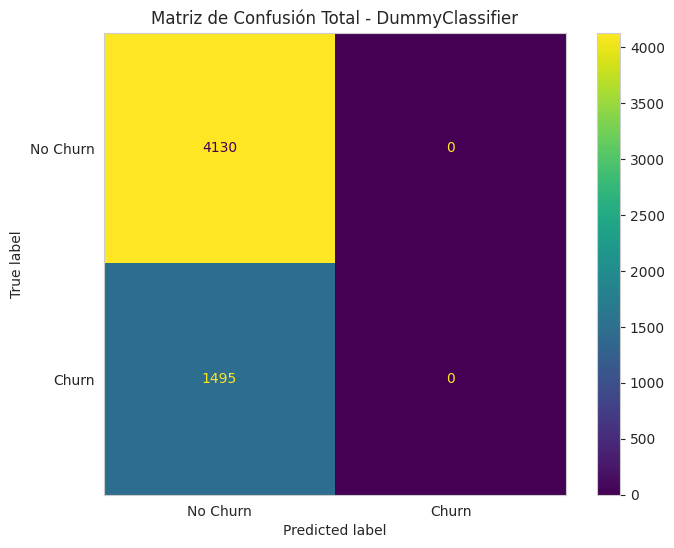

In [80]:
evaluar_modelo_cv(dummy, X_train, y_train, 'DummyClassifier')

### Análisis Tree Model


==================== DECISION TREE CLASSIFIER (Validación Cruzada) ====================
              precision    recall  f1-score   support

           0       0.85      0.88      0.87      4130
           1       0.64      0.57      0.60      1495

    accuracy                           0.80      5625
   macro avg       0.74      0.72      0.73      5625
weighted avg       0.79      0.80      0.79      5625



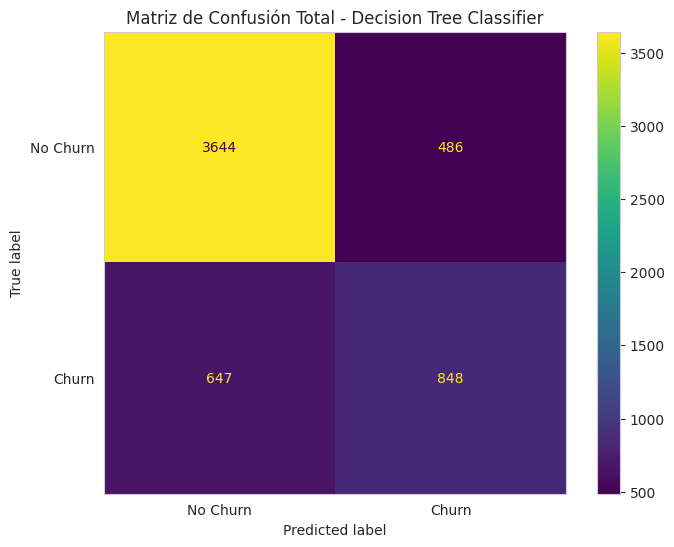

In [81]:
evaluar_modelo_cv(tree_model, X_train, y_train, 'Decision Tree Classifier')


==================== DECISION TREE CLASSIFIER - SMOOT (Validación Cruzada) ====================
              precision    recall  f1-score   support

           0       0.86      0.80      0.83      4130
           1       0.54      0.65      0.59      1495

    accuracy                           0.76      5625
   macro avg       0.70      0.73      0.71      5625
weighted avg       0.78      0.76      0.77      5625



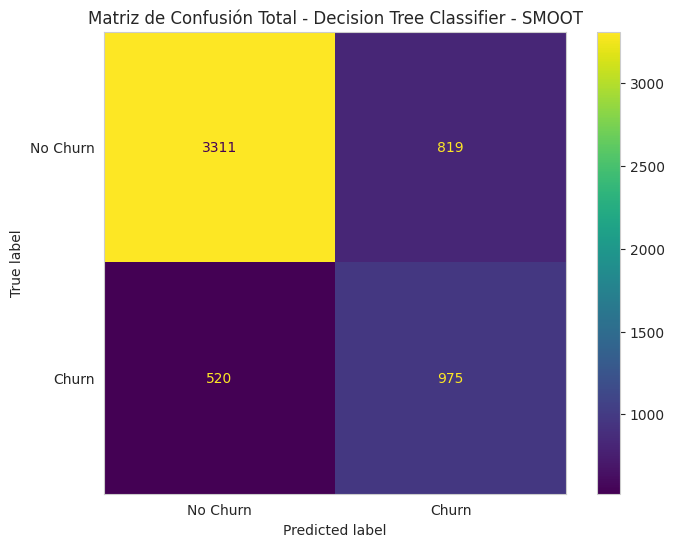

In [82]:
evaluar_modelo_cv(pipeline_balanceo(sm, tree_model), X_train, y_train, 'Decision Tree Classifier - SMOOT')


==================== DECISION TREE CLASSIFIER - NEARMISS_V3 (Validación Cruzada) ====================
              precision    recall  f1-score   support

           0       0.86      0.78      0.82      4130
           1       0.51      0.66      0.58      1495

    accuracy                           0.74      5625
   macro avg       0.69      0.72      0.70      5625
weighted avg       0.77      0.74      0.75      5625



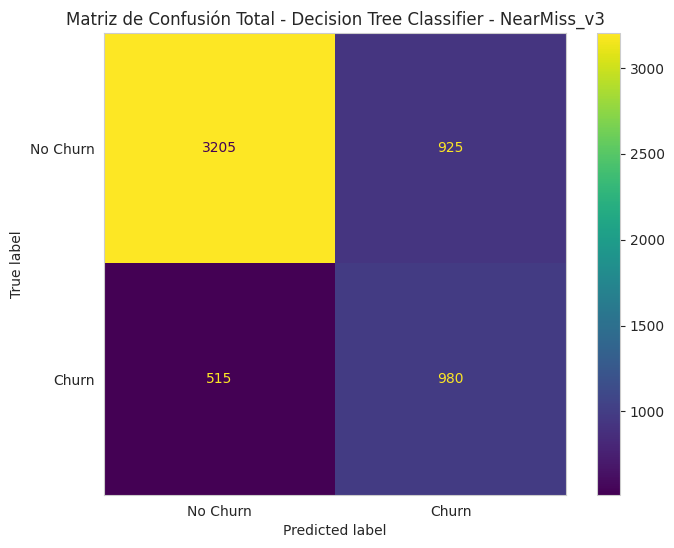

In [83]:
evaluar_modelo_cv(pipeline_balanceo(nm, tree_model), X_train, y_train, 'Decision Tree Classifier - NearMiss_v3')

### Análisis Random Forest Classifier


==================== RANDOM FOREST CLASSIFIER (Validación Cruzada) ====================
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      4130
           1       0.66      0.53      0.58      1495

    accuracy                           0.80      5625
   macro avg       0.75      0.71      0.73      5625
weighted avg       0.79      0.80      0.79      5625



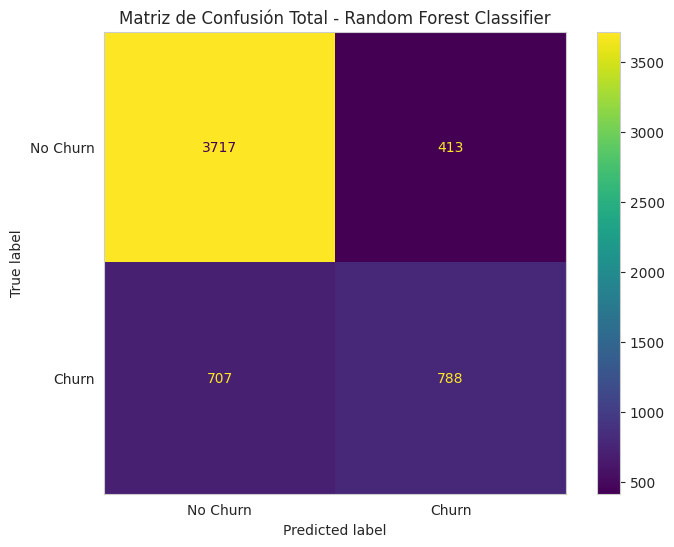

In [84]:
evaluar_modelo_cv(rf_model, X_train, y_train, 'Random Forest Classifier')


==================== RANDOM FOREST CLASSIFIER - SMOOT (Validación Cruzada) ====================
              precision    recall  f1-score   support

           0       0.87      0.83      0.85      4130
           1       0.58      0.65      0.62      1495

    accuracy                           0.78      5625
   macro avg       0.73      0.74      0.73      5625
weighted avg       0.79      0.78      0.79      5625



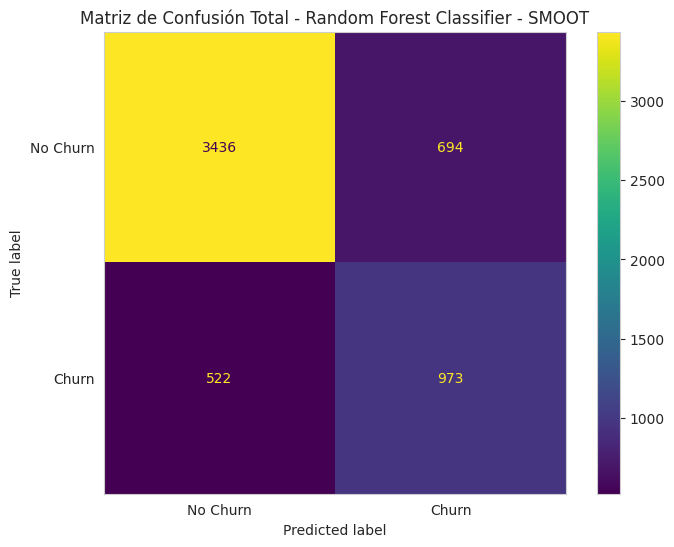

In [85]:
evaluar_modelo_cv(pipeline_balanceo(sm, rf_model), X_train, y_train, 'Random Forest Classifier - SMOOT')


==================== RANDOM FOREST CLASSIFIER - NEARMISS_V3 (Validación Cruzada) ====================
              precision    recall  f1-score   support

           0       0.87      0.80      0.84      4130
           1       0.55      0.66      0.60      1495

    accuracy                           0.77      5625
   macro avg       0.71      0.73      0.72      5625
weighted avg       0.78      0.77      0.77      5625



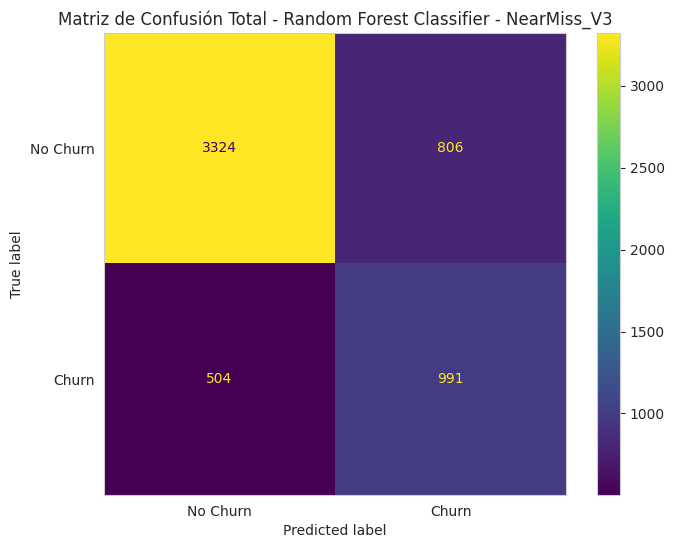

In [86]:
evaluar_modelo_cv(pipeline_balanceo(nm, rf_model), X_train, y_train, 'Random Forest Classifier - NearMiss_V3')

### Análisis XGBoost Classifier **


==================== XGBOOST CLASSIFIER (Validación Cruzada) ====================
              precision    recall  f1-score   support

           0       0.91      0.75      0.82      4130
           1       0.53      0.80      0.64      1495

    accuracy                           0.76      5625
   macro avg       0.72      0.77      0.73      5625
weighted avg       0.81      0.76      0.77      5625



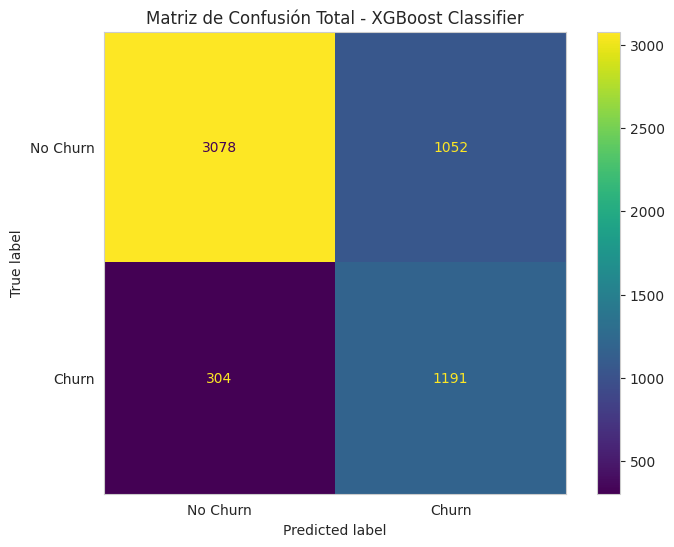

In [87]:
evaluar_modelo_cv(xgb_model, X_train, y_train, 'XGBoost Classifier')

## Feature Importance

In [88]:
import pandas as pd
import matplotlib.pyplot as plt

def importancia_variables(modelo, nombres_columnas):
    importancias = modelo.feature_importances_

    df_importancia = pd.DataFrame({'Variable': nombres_columnas, 'Importancia': importancias}).sort_values(by='Importancia', ascending=False)

    return df_importancia

### Random Forest - SMOOT

In [89]:
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

rf_model.fit(X_train_sm, y_train_sm)

importancia_variables(rf_model, nombres_cols)

,Variable,Importancia
14,onehotencoder__tipo_contrato_Mes a mes,0.178328
21,remainder__antiguedad_meses,0.131436
17,onehotencoder__metodo_pago_Cheque electrónico,0.106083
22,remainder__cobro_mensual,0.065286
16,onehotencoder__factura_electronica_Sí,0.060772
13,onehotencoder__tipo_contrato_Dos años,0.053764
7,onehotencoder__seguridad_online_Sí,0.045892
1,onehotencoder__tiene_pareja_Sí,0.043363
10,onehotencoder__soporte_tecnico_Sí,0.039846
5,onehotencoder__tipo_internet_Fibra óptica,0.037687


### XGBoost

In [90]:
xgb_model.fit(X_train, y_train)

importancia_variables(xgb_model, nombres_cols)

,Variable,Importancia
14,onehotencoder__tipo_contrato_Mes a mes,0.622096
5,onehotencoder__tipo_internet_Fibra óptica,0.111091
13,onehotencoder__tipo_contrato_Dos años,0.029058
4,onehotencoder__tipo_internet_DSL,0.023838
17,onehotencoder__metodo_pago_Cheque electrónico,0.019374
6,onehotencoder__tipo_internet_No,0.019254
21,remainder__antiguedad_meses,0.019055
3,onehotencoder__lineas_multiples_Sí,0.013436
12,onehotencoder__streaming_peliculas_Sí,0.012992
16,onehotencoder__factura_electronica_Sí,0.012027


### RFECV - XGBoost

In [91]:
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=5)

selector = RFECV(
    estimator=xgb_model,
    step=1,                  # Quita 1 variable a la vez para máxima precisión
    cv=skf,
    scoring='f1',
    n_jobs=-1                # Usa todos los núcleos del procesador
)

selector.fit(X_train, y_train)

RFECV(cv=StratifiedKFold(n_splits=5, random_state=5, shuffle=True),
      estimator=XGBClassifier(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=None, device=None,
                              early_stopping_rounds=None,
                              enable_categorical=False, eval_metric='logloss',
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.1,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=5, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=50, n_jobs=None,
                              num_parallel_tree=None, ...),
      n_jobs=-1, scoring='f1')

In [92]:
print(f"RFECV mantuvo {len(nombres_cols[selector.support_])} variables de las {len(nombres_cols)} originales.")

importancia_ranking = pd.DataFrame({'Variable': nombres_cols, 'Ranking': selector.ranking_}).sort_values(by='Ranking')

print(f'\nVariables eliminadas:\n{importancia_ranking[importancia_ranking['Ranking'] > 1]}')

RFECV mantuvo 20 variables de las 23 originales.

Variables eliminadas:
                                             Variable  Ranking
19  onehotencoder__metodo_pago_Tarjeta de crédito ...        2
20  onehotencoder__metodo_pago_Transferencia banca...        3
1                      onehotencoder__tiene_pareja_Sí        4


In [93]:
columnas_seleccionadas = nombres_cols[selector.support_]
importancia_variables(selector.estimator_, columnas_seleccionadas)

,Variable,Importancia
13,onehotencoder__tipo_contrato_Mes a mes,0.650723
4,onehotencoder__tipo_internet_Fibra óptica,0.123144
12,onehotencoder__tipo_contrato_Dos años,0.026357
3,onehotencoder__tipo_internet_DSL,0.023500
5,onehotencoder__tipo_internet_No,0.018756
18,remainder__antiguedad_meses,0.017353
16,onehotencoder__metodo_pago_Cheque electrónico,0.016579
2,onehotencoder__lineas_multiples_Sí,0.013455
11,onehotencoder__streaming_peliculas_Sí,0.013201
10,onehotencoder__streaming_tv_Sí,0.011379


### Evaluación del modelo "XGBoost Classifier + RFECV" con datos de entenamiento


==================== XGBOOST CLASSIFIER - RFECV (Validación Cruzada) ====================
              precision    recall  f1-score   support

           0       0.91      0.74      0.81      4130
           1       0.52      0.79      0.63      1495

    accuracy                           0.75      5625
   macro avg       0.72      0.77      0.72      5625
weighted avg       0.81      0.75      0.77      5625



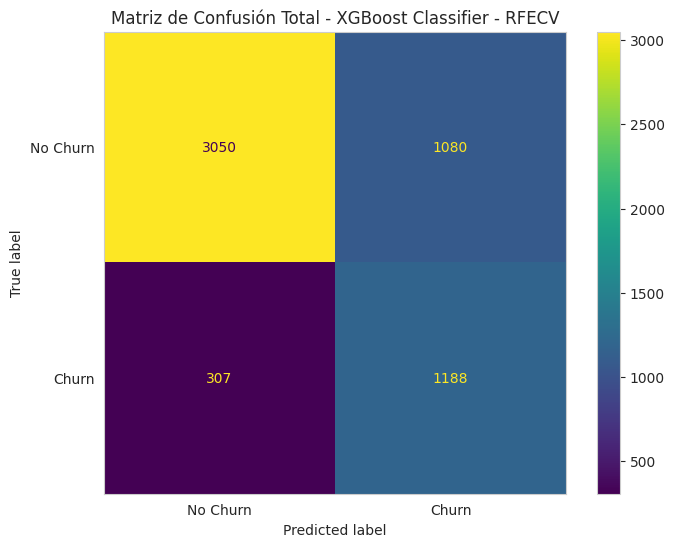

In [94]:
evaluar_modelo_cv(selector, X_train, y_train, 'XGBoost Classifier - RFECV')

## Evaluación Final con sets de prueba

============================== REPORTE: MODELO ORIGINAL (23 VAR) ==============================
              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1033
           1       0.51      0.78      0.62       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.80      0.75      0.76      1407


============================== REPORTE: MODELO RFECV (20 VAR) ==============================
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1033
           1       0.52      0.79      0.62       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.75      0.76      1407



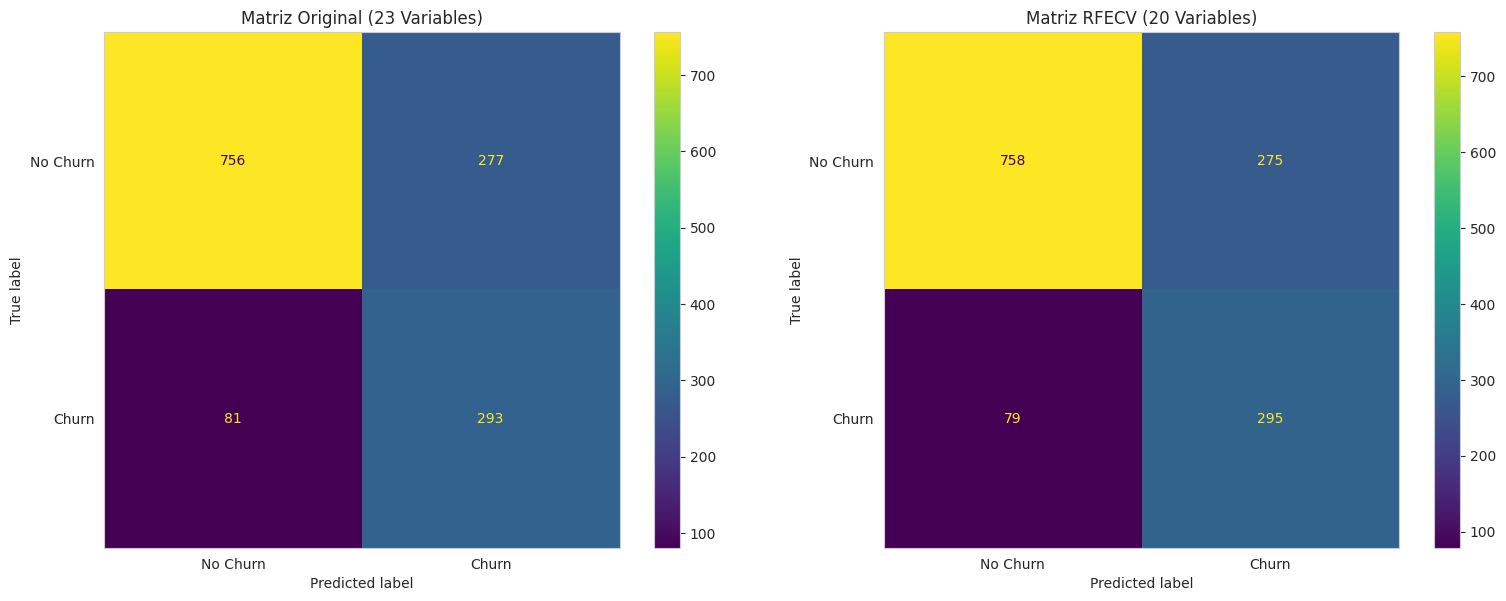

In [95]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred_original = xgb_model.predict(X_test)

y_pred_rfecv = selector.predict(X_test)

print(f"{'='*30} REPORTE: MODELO ORIGINAL (23 VAR) {'='*30}")
print(classification_report(y_test, y_pred_original))

print(f"\n{'='*30} REPORTE: MODELO RFECV (20 VAR) {'='*30}")
print(classification_report(y_test, y_pred_rfecv))


# Gráficos matriz de confusión
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Matriz Original
cm_orig = confusion_matrix(y_test, y_pred_original)
disp_orig = ConfusionMatrixDisplay(confusion_matrix=cm_orig, display_labels=['No Churn', 'Churn'])
disp_orig.plot(ax=ax[0])
ax[0].set_title("Matriz Original (23 Variables)")
ax[0].grid(False)

# Matriz RFECV
cm_rfecv = confusion_matrix(y_test, y_pred_rfecv)
disp_rfecv = ConfusionMatrixDisplay(confusion_matrix=cm_rfecv, display_labels=['No Churn', 'Churn'])
disp_rfecv.plot(ax=ax[1])
ax[1].set_title("Matriz RFECV (20 Variables)")
ax[1].grid(False)

plt.tight_layout()

plt.savefig('comparacion_matriz_confusion_modelos_finales.png', dpi=300, bbox_inches='tight')

plt.show()

# Informe Final: Estrategia Predictiva de Retención de Clientes - Telecom X

## 1. Introducción
El presente informe técnico detalla el desarrollo, evaluación y selección de la solución predictiva para la detección de abandono de clientes (**Churn**) en **Telecom X**. El objetivo central fue transitar de un análisis descriptivo a una herramienta proactiva de **Machine Learning** capaz de identificar patrones de fuga antes de que se materialicen, permitiendo a la dirección implementar estrategias de retención basadas en datos.

## 2. Rendimiento de los Modelos y Selección Técnica

Se llevó a cabo una fase de experimentación exhaustiva evaluando diversos algoritmos bajo tres escenarios de gestión de desbalance: datos originales (**sin sampleo**), **SMOTE** (Oversampling) y **NearMiss v3** (Undersampling). Para garantizar el máximo rendimiento de cada arquitectura, se realizó un **ajuste manual de hiperparámetros** en cada modelo probado, optimizando la profundidad de los árboles, el número de estimadores y las tasas de aprendizaje.

Los hallazgos principales se detallan a continuación:

* **Modelo de Referencia (Dummy Classifier):**
    Establecido como el *Baseline* para identificar el rendimiento mínimo esperado. Confirmó la complejidad del problema al obtener un **Recall del 0%** en la clase Churn, demostrando que sin un modelado avanzado es imposible detectar los patrones de abandono debido al sesgo de las clases mayoritarias.

* **Modelos de Árbol de Decisión (Decision Tree):**
    Tras optimizar manualmente parámetros como `max_depth` para evitar el sobreajuste, se evaluaron sus tres configuraciones. La versión sin sampleo obtuvo un Accuracy del 80% pero un Recall insuficiente del 57%. La implementación de técnicas de balanceo mejoró la detección (**Recall 65%-66%**), sin embargo, la precisión cayó significativamente (51%-54%), comprometiendo la fiabilidad de las alertas.

* **Modelos de Bosque Aleatorio (Random Forest):**
    Este algoritmo presentó un comportamiento más robusto tras el ajuste fino de sus hiperparámetros. La variante optimizada con **SMOTE** resultó ser la más equilibrada entre todos los modelos previos, logrando un **Recall del 65%**, una **Precisión del 58%** y un **F1-Score de 0.62**. A pesar de este equilibrio, el objetivo primordial del negocio requería una sensibilidad de detección aún mayor.

* **Modelo Seleccionado (XGBoost Classifier):**
    Fue seleccionado como la solución definitiva tras demostrar una superioridad técnica indiscutible. A través de un ajuste manual preciso de su configuración y el uso del parámetro interno `scale_pos_weight` (basado en la proporción real de las clases), se evitó la necesidad de manipular el dataset original externamente. En validación cruzada, alcanzó un **Recall superior del 80%** (identificando 8 de cada 10 fugas reales) con un **F1-Score de 0.64**, superando a cualquier otra arquitectura probada.

## 3. Optimización Champion: XGBoost + RFECV
Tras seleccionar el modelo XGBoost, se aplicó una **Eliminación Recursiva de Variables con Validación Cruzada (RFECV)**. Este proceso permitió simplificar el modelo reduciendo el set de 23 variables originales a las **20 variables con mayor peso predictivo**, eliminando el ruido estadístico.

La efectividad de esta optimización se validó mediante el uso de datos de test (`y_test`), los cuales nunca fueron vistos por los modelos durante el entrenamiento. Los resultados confirman que el modelo simplificado mantiene una alta capacidad de generalización:

![Comparativa visual de matrices de confusión: XGBoost vs XGBoost + RFECV](https://raw.githubusercontent.com/iesvs-campi/oracle-one-challenge-telecom-x-2/refs/heads/main/plot_final/comparacion_matriz_confusion_modelos_finales.png)

| Métrica (Clase Churn) | XGBoost Original (23 Var) | XGBoost + RFECV (20 Var) |
| :--- | :---: | :---: |
| **Recall (Detección de fugas)** | 78% | **79%** |
| **Precisión** | 51% | **52%** |
| **F1-Score** | 0.62 | **0.62** |

## 4. Factores Principales de Abandono (Feature Importance)
El análisis del modelo final determinó que la **antigüedad (tenure)** de los clientes no es el factor primordial para la deserción (ocupando el 6° lugar de importancia), siendo superada por variables contractuales y de infraestructura:

1.  **Tipo de Contrato (Mes a mes):** Es el factor determinante con un **65.07%** de peso predictivo. La falta de compromiso contractual a largo plazo es el indicador más crítico de vulnerabilidad.
2.  **Tecnología de Internet (Fibra óptica):** Representa el **12.31%** de la importancia. Este segmento requiere una revisión técnica inmediata por su alta tasa de cancelación.
3.  **Tipo de Contrato (Dos años):** Funciona como la barrera de salida más efectiva para la empresa.
4.  **Método de Pago (Cheque electrónico):** Los métodos manuales presentan una correlación significativamente mayor con la fuga que los pagos automatizados.

## 5. Estrategias de Retención Propuestas
Basándose en el comportamiento predictivo del modelo, se sugieren las siguientes acciones estratégicas:

* **Plan de Migración Contractual:** Diseñar incentivos agresivos para trasladar a los clientes del contrato "Mes a mes" hacia modalidades de permanencia anual. Atacar este punto impactaría directamente sobre el factor de riesgo del 65%.
* **Control de Calidad en Fibra Óptica:** Investigar la causa raíz de la insatisfacción en este segmento tecnológico para equilibrar la relación costo-beneficio percibida por el cliente.
* **Fomento de la Automatización:** Implementar bonificaciones por la migración de pagos manuales (Cheque electrónico) hacia débito automático para reducir la fricción en el proceso de cobro.
* **Fortalecimiento de Servicios de Valor Agregado:** Incentivar el uso de *Soporte Técnico* y *Seguridad Online*, ya que el modelo identifica que los clientes con estos servicios activos presentan una lealtad superior.

---
**Conclusión:** El despliegue del modelo **XGBoost + RFECV** permite a Telecom X identificar proactivamente al **79% de los clientes en riesgo de abandono**, optimizando la inversión en marketing y fidelización mediante un enfoque basado en variables de alto impacto.

## Extra: Visualización de los factores que influyen en la Cancelación

In [96]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

--- TASA DE CHURN POR CONTRATO ---
Churn                 No         Sí
tipo_contrato                      
Dos años       97.151335   2.848665
Mes a mes      57.290323  42.709677
Un año         88.722826  11.277174


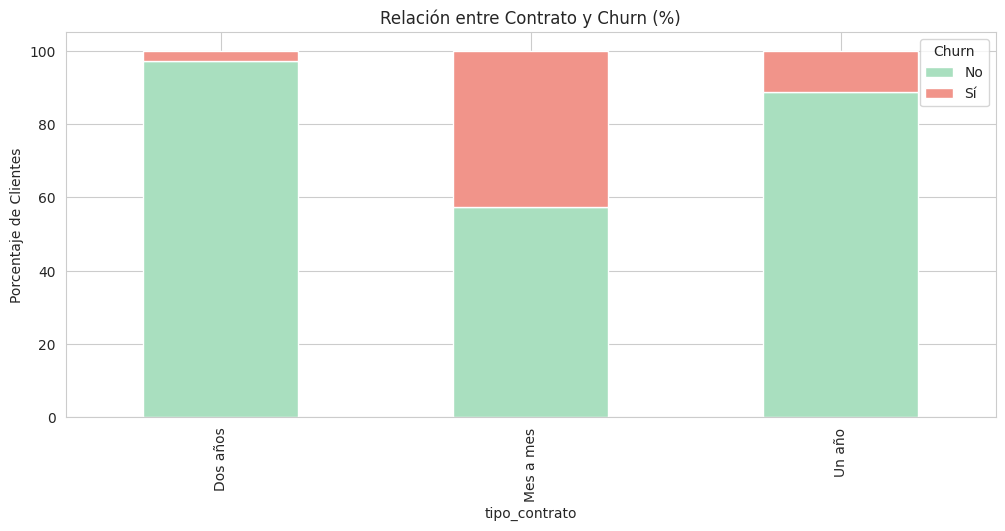

In [97]:
# DEMOSTRACIÓN: Tipo de Contrato
print("--- TASA DE CHURN POR CONTRATO ---")
tabla_contrato = datos.groupby('tipo_contrato')['Churn'].value_counts(normalize=True).unstack() * 100
print(tabla_contrato)
tabla_contrato.plot(kind='bar', stacked=True, color=['#A9DFBF', '#F1948A'])
plt.title("Relación entre Contrato y Churn (%)")
plt.ylabel("Porcentaje de Clientes")
plt.show()


--- TASA DE CHURN POR TIPO DE INTERNET ---
Churn                 No         Sí
tipo_internet                      
DSL            81.001656  18.998344
Fibra óptica   58.107235  41.892765
No             92.565789   7.434211


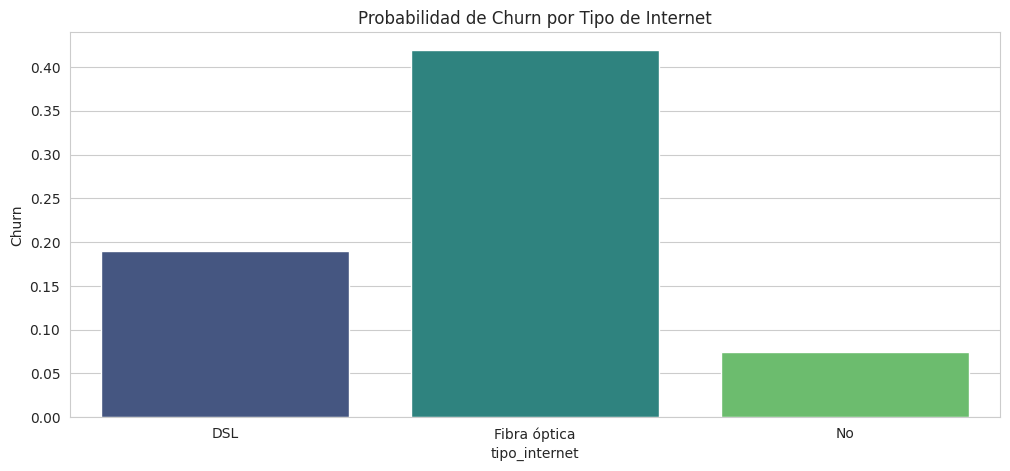

In [98]:
# DEMOSTRACIÓN: Fibra Óptica
print("\n--- TASA DE CHURN POR TIPO DE INTERNET ---")
tabla_internet = datos.groupby('tipo_internet')['Churn'].value_counts(normalize=True).unstack() * 100
print(tabla_internet)
sns.barplot(x=datos['tipo_internet'], y=datos['Churn'].map({'Sí': 1, 'No': 0}), errorbar=None, palette="viridis")
plt.title("Probabilidad de Churn por Tipo de Internet")
plt.show()


--- TASA DE CHURN POR MÉTODO DE PAGO ---
Churn                                       No         Sí
metodo_pago                                              
Cheque electrónico                   54.714588  45.285412
Cheque por correo                    80.798005  19.201995
Tarjeta de crédito (automática)      84.746877  15.253123
Transferencia bancaria (automática)  83.268482  16.731518


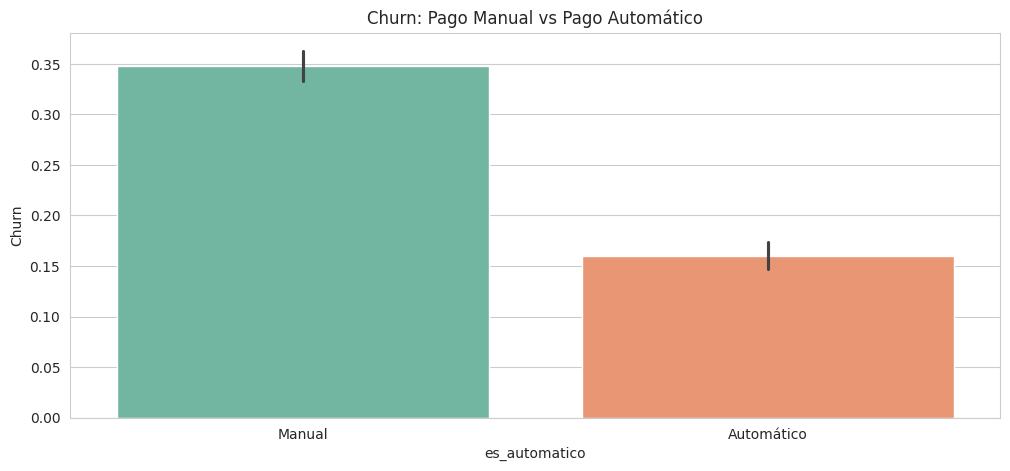

In [99]:
# DEMOSTRACIÓN: Métodos de Pago
print("\n--- TASA DE CHURN POR MÉTODO DE PAGO ---")
tabla_pago = datos.groupby('metodo_pago')['Churn'].value_counts(normalize=True).unstack() * 100
print(tabla_pago)
datos['es_automatico'] = datos['metodo_pago'].str.contains('automática').map({True: 'Automático', False: 'Manual'})
sns.barplot(x='es_automatico', y=datos['Churn'].map({'Sí': 1, 'No': 0}), data=datos, palette="Set2")
plt.title("Churn: Pago Manual vs Pago Automático")
plt.show()

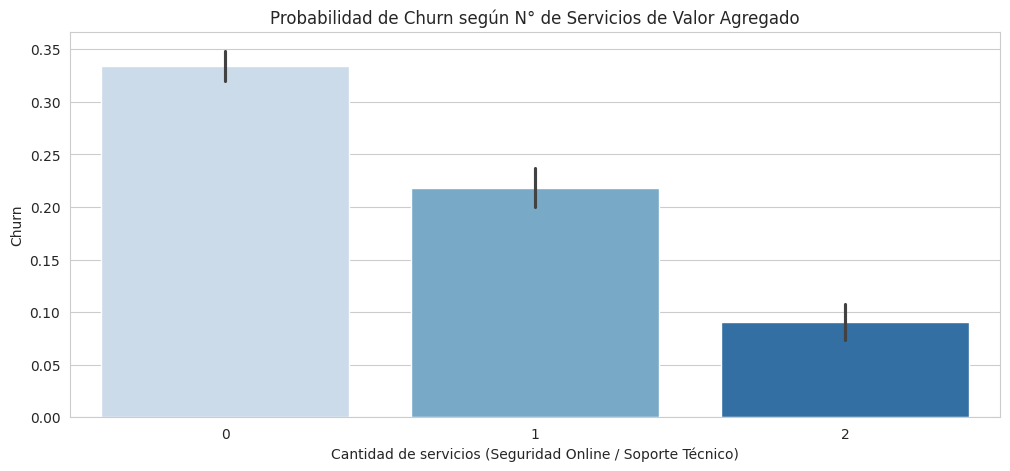

In [100]:
# DEMOSTRACIÓN: Servicios de Valor Agregado
# Creamos una columna que cuente cuántos servicios extra tiene el cliente
servicios_extra = ['seguridad_online', 'soporte_tecnico']
datos['conteo_servicios'] = (datos[servicios_extra] == 'Sí').sum(axis=1)
sns.barplot(x='conteo_servicios', y=datos['Churn'].map({'Sí': 1, 'No': 0}), data=datos, palette="Blues")
plt.title("Probabilidad de Churn según N° de Servicios de Valor Agregado")
plt.xlabel("Cantidad de servicios (Seguridad Online / Soporte Técnico)")
plt.show()